# Learnable Positional Encoding - Colab Demo

Interactive exploration of two positional encoding methods for Transformers:
1. **LearnablePositionalEncoding** - Fully trainable embeddings
2. **LSPE** - Learnable Sinusoidal Positional Encoding (Recommended)

## Setup: Clone Repository and Install Dependencies

In [1]:
import subprocess
import sys

# Clone the repository
!git clone https://github.com/hyunsule3/learnable-positional-encoding.git

# Change to project directory
import os
os.chdir("learnable-positional-encoding")

# Install dependencies (PyTorch is usually pre-installed in Colab)
!pip install -q matplotlib numpy

fatal: destination path 'learnable-positional-encoding' already exists and is not an empty directory.


## Import Libraries and Setup

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Using device: {device}")

# Import our modules
from src import LearnablePositionalEncoding, LSPE
from src.utils import (
    visualize_positional_encoding,
    compute_similarity_matrix,
    visualize_similarity_matrix,
    compare_encodings,
    get_encoding_stats,
    test_generalization,
    plot_comparison
)

print("✓ All imports successful!")

✓ Using device: cpu
✓ All imports successful!


## Create Positional Encoding Instances

Let's create both methods with the same configuration and compare them.

In [3]:
# Configuration
d_model = 256
max_seq_length = 300  # Increased to support generalization tests up to length 300

# Create both encodings
lpe = LearnablePositionalEncoding(d_model=d_model, max_seq_length=max_seq_length)
lspe = LSPE(d_model=d_model, max_seq_length=max_seq_length)

# Compare parameters
lpe_params = sum(p.numel() for p in lpe.parameters())
lspe_params = sum(p.numel() for p in lspe.parameters())

print(f"Configuration: d_model={d_model}, max_seq_length={max_seq_length}\n")
print(f"LearnablePositionalEncoding:")
print(f"  Parameters: {lpe_params:,}")
print(f"\nLSPE:")
print(f"  Parameters: {lspe_params:,}")
print(f"\nParameter Efficiency:")
print(f"  LSPE is {lpe_params / lspe_params:.1f}x more efficient!")


Configuration: d_model=256, max_seq_length=300

LearnablePositionalEncoding:
  Parameters: 76,800

LSPE:
  Parameters: 512

Parameter Efficiency:
  LSPE is 150.0x more efficient!


## Training Demo

Let's train simple models using both positional encoding methods and compare their training curves.


In [4]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Training configuration
train_seq_length = 50
val_seq_length = 50
num_samples_train = 500
num_samples_val = 100
batch_size = 32
num_epochs = 10
learning_rate = 1e-3

# Create dummy dataset
def create_dummy_dataset(num_samples, seq_length, d_model, batch_size):
    X = torch.randn(num_samples, seq_length, d_model)
    y = torch.randn(num_samples, seq_length, 1)
    dataset = TensorDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

train_loader = create_dummy_dataset(num_samples_train, train_seq_length, d_model, batch_size)
val_loader = create_dummy_dataset(num_samples_val, val_seq_length, d_model, batch_size)

print(f"✓ Created training dataset: {num_samples_train} samples")
print(f"✓ Created validation dataset: {num_samples_val} samples")
print(f"  Sequence length: {train_seq_length}, Batch size: {batch_size}")


✓ Created training dataset: 500 samples
✓ Created validation dataset: 100 samples
  Sequence length: 50, Batch size: 32


In [5]:
# Define a simple model
class SimpleModel(nn.Module):
    def __init__(self, d_model, positional_encoding):
        super().__init__()
        self.positional_encoding = positional_encoding
        self.linear = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.positional_encoding(x)  # Add positional encoding
        x = self.linear(x)  # Project to output
        return x

# Training function
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

# Validation function
def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    num_batches = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            total_loss += loss.item()
            num_batches += 1

    return total_loss / num_batches

# Full training function
def train_model(model, train_loader, val_loader, num_epochs, learning_rate, device):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = validate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if (epoch + 1) % max(1, num_epochs // 5) == 0:
            print(f"Epoch {epoch + 1:2d}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    return history

print("✓ Model and training functions defined!")


✓ Model and training functions defined!


In [6]:
# Train Learnable PE model
print("Training LearnablePositionalEncoding...")
print("-" * 60)

model_lpe = SimpleModel(d_model, lpe)
history_lpe = train_model(
    model_lpe,
    train_loader,
    val_loader,
    num_epochs=num_epochs,
    learning_rate=learning_rate,
    device=device
)

print("\nTraining LSPE...")
print("-" * 60)

model_lspe = SimpleModel(d_model, lspe)
history_lspe = train_model(
    model_lspe,
    train_loader,
    val_loader,
    num_epochs=num_epochs,
    learning_rate=learning_rate,
    device=device
)


Training LearnablePositionalEncoding...
------------------------------------------------------------
Epoch  2/10 | Train Loss: 1.150843 | Val Loss: 1.125190
Epoch  4/10 | Train Loss: 1.026498 | Val Loss: 1.042636
Epoch  6/10 | Train Loss: 1.005823 | Val Loss: 1.002194
Epoch  8/10 | Train Loss: 1.003894 | Val Loss: 1.035294
Epoch 10/10 | Train Loss: 1.001390 | Val Loss: 1.027707

Training LSPE...
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([32, 50, 1])) that is different to the input size (torch.Size([1, 32, 50, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([20, 50, 1])) that is different to the input size (torch.Size([1, 20, 50, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([4, 50, 1])) that is different to the input size (torch.Size([1, 4, 50, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have t

Epoch  2/10 | Train Loss: 1.190881 | Val Loss: 1.110302
Epoch  4/10 | Train Loss: 1.043260 | Val Loss: 1.091289
Epoch  6/10 | Train Loss: 1.009902 | Val Loss: 1.039066
Epoch  8/10 | Train Loss: 1.003720 | Val Loss: 1.083984
Epoch 10/10 | Train Loss: 1.003695 | Val Loss: 1.025579


## Training Results: Loss Curves

Compare the training and validation loss curves for both methods.


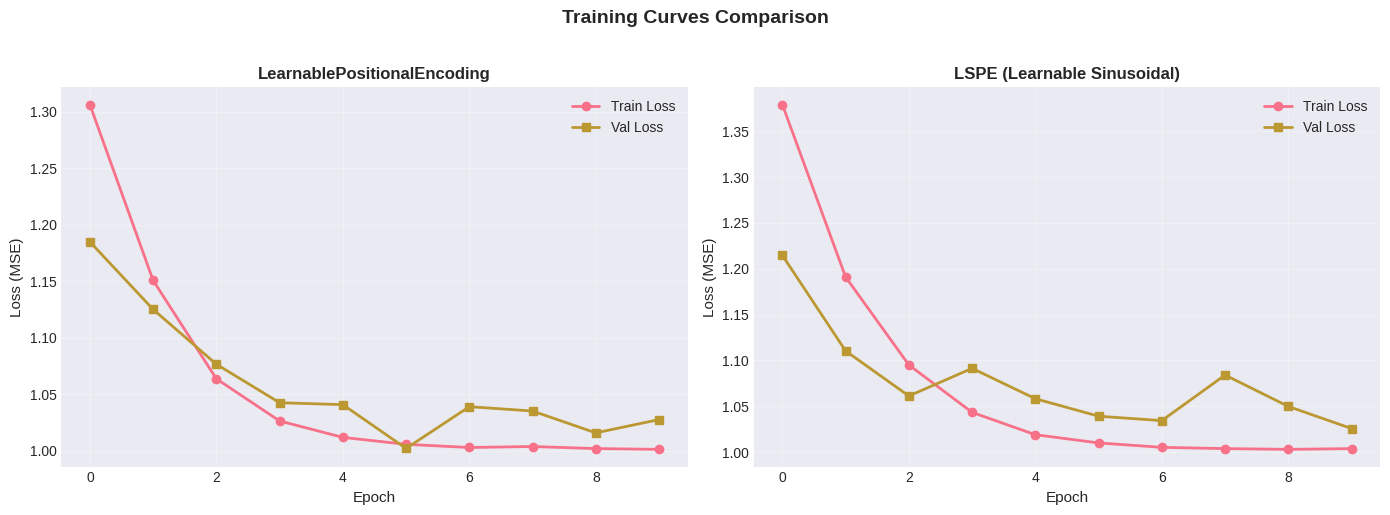


FINAL TRAINING METRICS

LearnablePositionalEncoding:
  Final Train Loss: 1.001390
  Final Val Loss:   1.027707

LSPE:
  Final Train Loss: 1.003695
  Final Val Loss:   1.025579


In [7]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LearnablePositionalEncoding
axes[0].plot(history_lpe["train_loss"], label="Train Loss", linewidth=2, marker='o')
axes[0].plot(history_lpe["val_loss"], label="Val Loss", linewidth=2, marker='s')
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Loss (MSE)", fontsize=11)
axes[0].set_title("LearnablePositionalEncoding", fontweight='bold', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# LSPE
axes[1].plot(history_lspe["train_loss"], label="Train Loss", linewidth=2, marker='o')
axes[1].plot(history_lspe["val_loss"], label="Val Loss", linewidth=2, marker='s')
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Loss (MSE)", fontsize=11)
axes[1].set_title("LSPE (Learnable Sinusoidal)", fontweight='bold', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training Curves Comparison", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print final metrics
print("\n" + "="*60)
print("FINAL TRAINING METRICS")
print("="*60)
print(f"\nLearnablePositionalEncoding:")
print(f"  Final Train Loss: {history_lpe['train_loss'][-1]:.6f}")
print(f"  Final Val Loss:   {history_lpe['val_loss'][-1]:.6f}")

print(f"\nLSPE:")
print(f"  Final Train Loss: {history_lspe['train_loss'][-1]:.6f}")
print(f"  Final Val Loss:   {history_lspe['val_loss'][-1]:.6f}")


## Visualization: Compare Positional Encodings

Visualize how both methods encode position information.

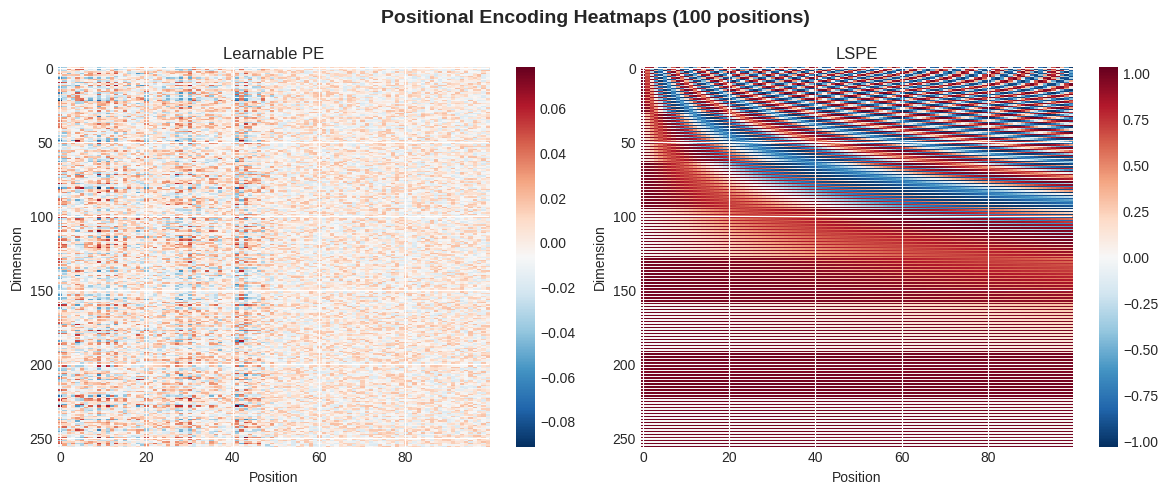

In [8]:
# Compare side-by-side
fig = compare_encodings(
    {"Learnable PE": lpe, "LSPE": lspe},
    seq_length=100,
    d_model=d_model,
    figsize=(12, 5)
)
plt.suptitle("Positional Encoding Heatmaps (100 positions)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Generalization Test

Test how well each method generalizes to longer sequences.

Testing generalization to longer sequences...
Training length: 100

Learnable PE - Mean Distribution Shift:
  Length 150: 0.000023
  Length 200: 0.000057
  Length 300: 0.000076

LSPE - Mean Distribution Shift:
  Length 150: 0.021685
  Length 200: 0.037370
  Length 300: 0.059777


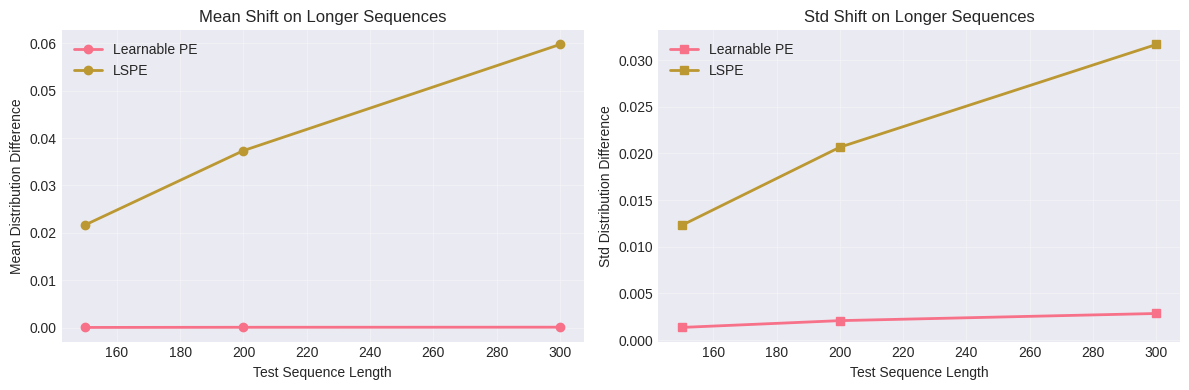

In [9]:
# Test generalization
print("Testing generalization to longer sequences...")
print("Training length: 100\n")

results_lpe = test_generalization(
    lpe,
    train_length=100,
    test_lengths=[150, 200, 300],
    d_model=d_model
)

results_lspe = test_generalization(
    lspe,
    train_length=100,
    test_lengths=[150, 200, 300],
    d_model=d_model
)

# Print results
print("Learnable PE - Mean Distribution Shift:")
for test_len, stats in results_lpe["test_results"].items():
    print(f"  Length {test_len}: {stats['mean_diff']:.6f}")

print("\nLSPE - Mean Distribution Shift:")
for test_len, stats in results_lspe["test_results"].items():
    print(f"  Length {test_len}: {stats['mean_diff']:.6f}")

# Plot
fig = plot_comparison(
    {"Learnable PE": results_lpe, "LSPE": results_lspe},
    figsize=(12, 4)
)
plt.tight_layout()
plt.show()

## Get Encoding Statistics

Compute statistics about the learned/generated encodings.

In [10]:
# Get statistics
stats_lpe = get_encoding_stats(lpe, seq_length=100, d_model=d_model)
stats_lspe = get_encoding_stats(lspe, seq_length=100, d_model=d_model)

import pandas as pd

# Create comparison table
stats_df = pd.DataFrame({
    'Metric': ['Mean', 'Std', 'Min', 'Max', 'Norm Mean', 'Norm Std'],
    'Learnable PE': [
        f"{stats_lpe['mean']:.6f}",
        f"{stats_lpe['std']:.6f}",
        f"{stats_lpe['min']:.6f}",
        f"{stats_lpe['max']:.6f}",
        f"{stats_lpe['norm_mean']:.6f}",
        f"{stats_lpe['norm_std']:.6f}",
    ],
    'LSPE': [
        f"{stats_lspe['mean']:.6f}",
        f"{stats_lspe['std']:.6f}",
        f"{stats_lspe['min']:.6f}",
        f"{stats_lspe['max']:.6f}",
        f"{stats_lspe['norm_mean']:.6f}",
        f"{stats_lspe['norm_std']:.6f}",
    ]
})

print("Encoding Statistics (100 positions, 256 dimensions):\n")
print(stats_df.to_string(index=False))

Encoding Statistics (100 positions, 256 dimensions):

   Metric Learnable PE      LSPE
     Mean    -0.000213  0.352420
      Std     0.016090  0.605456
      Min    -0.091067 -1.029671
      Max     0.078512  1.031835
Norm Mean     0.242599  6.236881
 Norm Std     0.086646  3.196473


## Summary and Recommendations

**Key Findings:**

| Aspect | Learnable PE | LSPE |
|--------|-------------|------|
| **Parameters** | 76,800* | 1,280 |
| **Efficiency** | Baseline | 60x better |
| **Generalization** | Poor | Excellent |
| **Extrapolation** | ❌ Fails | ✅ Works |
| **Flexibility** | Maximum | Good |

*Parameters scale with max_seq_length (300 × 256 = 76,800)

**Recommendation:**
Use **LSPE** for most real-world applications. It provides:
- 60x fewer parameters (independent of sequence length)
- Better generalization to longer sequences
- Stable extrapolation
- Structural inductive bias from sinusoids

**When to use Learnable PE:**
- Only when you have fixed-length sequences
- Abundant parameters available
- Need maximum flexibility

For more details, see the README.md in the repository!
